# Training a multilayer perceptron from scratch, in JAX

Build an MLP out of nothing but arrays — the parameters, the forward pass, the optimizers, and the training
loop. `jax.grad` gives you backpropagation; write everything else yourself.

The target is a sum of four sine waves of **equal amplitude** at frequencies 1, 2, 4 and 8, taking the mean to apply equal amplitudes. 

## Sourcing
I used Claude for help understanding Jax and implementation things (getting right shapes, proper updating, debugging) and also quite obviously for plotting. I did ask for guiding thoughts and code skeletons so that I can actually learn this on my own, and my hope/plan is that as I get more comfortable with programming again and machine learning I will use it less and less as a crutch and more as a lever!

In [1]:
# !pip install -q jax jaxlib matplotlib

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

print("jax", jax.__version__, "| devices:", jax.devices())

jax 0.11.2 | devices: [CpuDevice(id=0)]


## The data


In [2]:
FREQS = jnp.array([1.0, 2.0, 4.0, 8.0])
NOISE_STD = 0.02

def target_fn(x): #defines our function f(x) = sin(2(pi)f*x)
    """x: (n,) -> (n,)"""
    return jnp.mean(jnp.sin(2 * jnp.pi * FREQS * x[:, None]), axis=-1)


def make_data(key, n=2048, noise_std=NOISE_STD): #noisy input from which we are trying to predict f(x)
    """Returns X: (n, 1), Y: (n, 1)"""
    key_x, key_noise = jax.random.split(key)
    x = jax.random.uniform(key_x, (n,), minval=0.0, maxval=1.0)
    y = target_fn(x) + noise_std * jax.random.normal(key_noise, (n,))
    return x[:, None], y[:, None]

root = jax.random.key(5)
data_key, init_key, train_key = jax.random.split(root,3)
X, Y = make_data(data_key)

print(f"target variance : {float(Y.var()):.4f}")   # silly baseline: the error you get by predicting the mean
print(f"noise floor : {(NOISE_STD)**2}") #what you get if you perfectly predict the function,beyond this you start fitting noise

target variance : 0.1256
noise floor : 0.0004


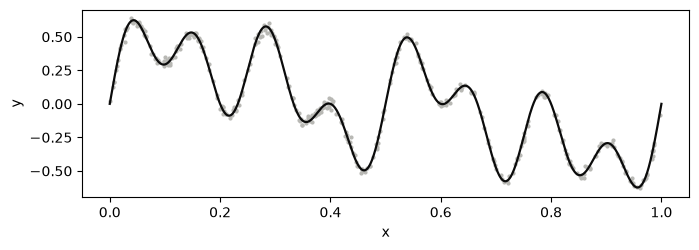

In [3]:
grid = jnp.linspace(0, 1, 1000)
plt.figure(figsize=(7, 2.6))
plt.scatter(np.array(X[:400, 0]), np.array(Y[:400, 0]), s=4, color="#b8b8b4")
plt.plot(np.array(grid), np.array(target_fn(grid)), color="#0b0b0b", lw=1.6)
plt.xlabel("x"); plt.ylabel("y"); plt.tight_layout(); plt.show()

---
## 1. The network

Write three functions:

- `init_mlp(key, layer_sizes)` — the parameters. Think about what a layer actually *is*, and about the scale
  of the initial random draw.
- `forward(params, x)` — `activation` on the hidden layers, nothing on the output.
- `loss_fn(params, x, y)` — mean squared error.

Use `[1, 128, 128, 1]` for layer sizes and n_in/out

In [4]:
layer_sizes = [1,128,128,1]

def init_mlp(init_key=init_key,layer_sizes=layer_sizes):
    n_layers = len(layer_sizes)-1 #not doing anyt to last layer (output)
    init_keys = jax.random.split(init_key,n_layers)
    params = []
    for key, (n_in,n_out) in zip(init_keys,zip(layer_sizes[:-1],layer_sizes[1:])): #storing weights based on sizes
        W = jax.random.normal(key,(n_in,n_out))*jnp.sqrt(1/n_in)
        b = jnp.zeros((n_out,))
        params.append({"W":W,"b":b})
    return params


def fwd(params, X):
    "layering and activation"
    A = X
    for layer in params[:-1]:
        A = jnp.tanh(A @ layer["W"] +layer["b"])
    last_layer = params[-1]
    return A @ last_layer["W"] + last_layer["b"]
                 
def loss_func(params, X,Y):
    "define MSE loss"
    pred = fwd(params,X)
    assert pred.shape==Y.shape
    return jnp.mean((pred-Y)**2)

eval_loss = jax.jit(loss_func)

---
## 3. The optimizers

Implement each one from its update equation:

1. **Gradient descent** — full batch, one step per epoch
2. **SGD** — minibatch
3. **SGD with momentum**
4. **Adagrad**
5. **Adam**
6. **Muon** — if you get that far, but it is waaaay trickier so don't get discouraged if you stop at Adam!

Look the update rules up. Muon is recent and not in textbooks:
[kellerjordan.github.io/posts/muon](https://kellerjordan.github.io/posts/muon/).

### GD and SGD

In [5]:
#GD/SGD step only differs by batch size , GD full batch ie batch_size = 2048 and n_batches = 1, SGD n_batches = X.shape[0] // batch_size


def sgd(lr):
    def init(params):
        return ()                             

    def update(grads, state, params):
        new_params = jax.tree.map(lambda p, g: p - lr * g, params, grads)
        return new_params, state

    return init, update


### SGD w/Momentum

In [6]:
# v_t = c*v_{t-1}+g_t , g_t = grad L wrt t , c is the momentum constant
#   theta_t = theta_{t-1} - lr * v_t #update rule
#   State: v, same pytree structure as params, initialised to zero.

def sgd_momentum(lr,c):
    def init(params):
        return jax.tree.map(jnp.zeros_like, params)     # v_0 = 0
        
    def update(grads, v, params):
        new_v = jax.tree.map(lambda v,g: c*v+g, v, grads)
        new_params = jax.tree.map(lambda p,v: p-lr*v, params, new_v)
        return new_params, new_v
 
    return init, update
    

### AdaGrad

In [7]:
# update: x_{t+1} = x_t-lr*(eps*eye(n)+G_t)^{-1/2} g_t
#   G_t = G_{t-1} + g_t**2    State: G (running SUM of squared gradients), zeros like params.

def adagrad(lr, eps=1e-8):
    def init(params):
        return jax.tree.map(jnp.zeros_like, params)     # G_0 = 0
 
    def update(grads, old_G, params):
        new_G = jax.tree.map(lambda G,g:G+g**2, old_G, grads)
        new_params = jax.tree.map(lambda G,g,p: p-lr*(g/jnp.sqrt(eps+G)) , new_G, grads,params)
        return new_params, new_G
 
    return init, update

### Adam 

In [8]:
# ---------------------------------------------------------------------------
# 5. Adam
# lr=1e-3, b1=0.9, b2=0.999, eps=1e-8 , from paper
#   t      = t + 1                                   (first update uses t = 1)
#   m_t    = b1 * m_{t-1} + (1 - b1) * g_t
#   v_t    = b2 * v_{t-1} + (1 - b2) * g_t**2
#   m_hat  = m_t / (1 - b1**t)                       (bias correction)
#   v_hat  = v_t / (1 - b2**t)
#   theta  = theta - lr * m_hat / (sqrt(v_hat) + eps)
#   State: (m, v, t). t is a jnp array, not a Python int, so its type is the
#   same before and after the first jitted step (avoids a retrace).
# ---------------------------------------------------------------------------
def adam(lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
    def init(params):
        m = jax.tree.map(jnp.zeros_like, params)
        v = jax.tree.map(jnp.zeros_like, params)
        t = jnp.array(0, dtype=jnp.int32)
        state = (m,v,t)
        return state
 
    def update(grads, state, params):
        m, v, t = state
        t = t+1
        m = jax.tree.map(lambda m,g: b1*m+(1-b1)*g, m, grads)
        v = jax.tree.map(lambda v,g: b2*v+(1-b2)*g**2, v,grads)
        c1 = 1-b1**t
        c2 = 1-b2**t
        new_params = jax.tree.map(lambda m,v,p:p-lr*(m/c1)/(jnp.sqrt(v/c2)+eps) , m,v,params)
        return new_params, (m, v, t)
 
    return init, update

---
## 2. The training loop

Minibatches of 128, reshuffled every epoch, 400 epochs. Get gradients with `jax.grad`. Wrap the step in
`@jax.jit` or it will be slow.

In [9]:
from typing import NamedTuple

class Result(NamedTuple):
    params: list
    step_losses: jax.Array
    epoch_losses: jax.Array

In [10]:
n_epochs=400

def make_step(update):
    @jax.jit
    def step(params, opt_state, xb, yb):
        loss, grads = jax.value_and_grad(loss_func)(params, xb, yb)
        params, opt_state = update(grads, opt_state, params)
        return params, opt_state, loss
    return step

#shufflin and trainin

def get_batches(key,X,Y,batch_size):
    """Returns Xb, Yb of shape (n_batches, batch_size, 1), freshly shuffled."""
    N = X.shape[0]
    n_batches = N//batch_size
    perm = jax.random.permutation(key,N)
    idx = perm[:n_batches*batch_size].reshape(n_batches,batch_size)
    return X[idx], Y[idx]

def train(optimizer,X,Y,params,train_key,n_epochs,batch_size):
    init, update = optimizer
    opt_state = init(params)
    step = make_step(update)                 # compiled separately for each optimizer
    step_losses, epoch_losses = [],[]
    for epoch in range(n_epochs):
        train_key, subkey = jax.random.split(train_key)
        X_b,Y_b = get_batches(subkey,X,Y,batch_size)
        for x_b,y_b in zip(X_b,Y_b):
            params, opt_state, loss = step(params,opt_state,x_b,y_b)
            step_losses.append(loss)
        epoch_losses.append(eval_loss(params,X,Y)) #compile loss_func once and re-use for the rest of the epochs instead of eager implementation
    return Result(params, jnp.stack(step_losses), jnp.stack(epoch_losses))

In [11]:
# training loop

runs = {
    "GD":       (sgd(lr=0.01),       2048),
    "SGD":      (sgd(lr=0.01),       128),
    "Momentum": (sgd_momentum(lr=0.01,c=0.7),  128),
    "Adagrad": (adagrad(lr=0.01,), 128),
    "Adam": (adam(lr=0.001, b1=0.9, b2=0.999, eps=1e-8), 128),
}

params0 = init_mlp()

def run_all(runs, X_in):
    return {name: train(opt, X_in, Y, params0, train_key, n_epochs, batch_size=bs)
            for name, (opt, bs) in runs.items()}

In [12]:
results = run_all(runs,X)

# results = {
 #   "GD":   (final_params, step_losses, epoch_losses),
 #   "SGD":  (final_params, step_losses, epoch_losses),
 #   ...
# }

---
## 4. What to report

- **All six loss curves on one set of axes**, log scale on y. Plot against both epochs and steps

#### Plotting

In [13]:
def ema(y, beta=0.98, log_space=True):
    """Bias-corrected exponential moving average; with log_space=True it smooths log(loss)."""
    y = np.asarray(y, dtype=float)
    z = np.log(np.maximum(y, 1e-300)) if log_space else y
    out = np.empty_like(z); s = 0.0
    for t, zt in enumerate(z, start=1):
        s = beta * s + (1 - beta) * zt
        out[t - 1] = s / (1 - beta ** t)          # bias correction, same idea as in Adam
    return np.exp(out) if log_space else out

def moving_average(y, window=51):
    """Centered moving average (no lag); returns the step numbers it applies to."""
    y = np.asarray(y, dtype=float)
    sm = np.convolve(y, np.ones(window) / window, mode="valid")
    x = np.arange(window // 2 + 1, len(y) - window // 2 + 1)   # centre of each window
    return x, sm

def log_limits(arrays, floor=None, q=100, pad=1.5):
    """Log-scale y-limits from finite, positive values; the top ignores the highest (100-q)% of values.
    If floor is given, the lower limit is extended down to include it."""
    vals = np.concatenate([np.asarray(a).ravel() for a in arrays])
    vals = vals[np.isfinite(vals) & (vals > 0)]
    lo = vals.min() if floor is None else min(vals.min(), floor)
    return lo / pad, np.percentile(vals, q) * pad

def plot_loss_curves(results, suptitle=None, beta=0.98):
    """Full-data loss per epoch (left) and smoothed minibatch loss per step (right)."""
    fig, (ax_ep, ax_st) = plt.subplots(1, 2, figsize=(15, 5))
    for name, r in results.items():
        ep, st = np.asarray(r.epoch_losses), np.asarray(r.step_losses)
        steps = np.arange(1, len(st) + 1)
        ax_ep.plot(np.arange(1, len(ep) + 1), ep, label=name)
        raw, = ax_st.plot(steps, st, lw=0.5, alpha=0.25)
        smooth = st if name == "GD" else ema(st, beta)          # GD's step loss is already noise-free
        ax_st.plot(steps, smooth, color=raw.get_color(), lw=1.2, label=name)
    for ax, xlabel, title, field in [(ax_ep, "epoch", "Full-data loss (end of each epoch)", "epoch_losses"),
                                     (ax_st, "step", "Minibatch loss (before each update)", "step_losses")]:
        ax.set(yscale="log", xlabel=xlabel, ylabel="MSE", title=title)
        ax.set_ylim(*log_limits([getattr(r, field) for r in results.values()]))
        ax.text(0.02, 0.02, rf"noise floor $\sigma^2$ = {NOISE_STD**2:.1e}",
                transform=ax.transAxes, fontsize=8, color="gray")
        ax.legend(fontsize=8)
    ax_st.set_xscale("log")
    if suptitle: fig.suptitle(suptitle)
    plt.tight_layout(); plt.show()


def plot_fits(results, X, Y, to_input=lambda x: x, suptitle=None):
    """MLP prediction vs target on [0, 1]. X, Y are in ORIGINAL units; to_input maps x to network input."""
    grid = jnp.linspace(0, 1, 1000)
    n = len(results); ncols = 3; nrows = -(-n // ncols)             # ceiling division
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3 * nrows), sharex=True, sharey=True, squeeze=False)
    for ax, (name, r) in zip(axes.flat, results.items()):
        pred = np.asarray(fwd(r.params, to_input(grid)[:, None])[:, 0])
        ax.scatter(np.asarray(X[:, 0]), np.asarray(Y[:, 0]), s=2, color="#d0d0cc", zorder=0)
        ax.plot(grid, np.asarray(target_fn(grid)), color="black", lw=1.2, label="target")
        if np.all(np.isfinite(pred)):
            ax.plot(grid, pred, color="C1", lw=1.2, label="MLP")
        else:
            ax.text(0.5, 0.5, "diverged (non-finite output)", transform=ax.transAxes, ha="center")
        ax.set_title(f"{name}  (final loss {float(r.epoch_losses[-1]):.2e})", fontsize=10)
    for ax in axes.flat[n:]:
        ax.axis("off")
    axes.flat[0].legend(fontsize=8)
    for ax in axes[-1]: ax.set_xlabel("x")
    for ax in axes[:, 0]: ax.set_ylabel("y")
    if suptitle: fig.suptitle(suptitle)
    plt.tight_layout(); plt.show()

#### Plots

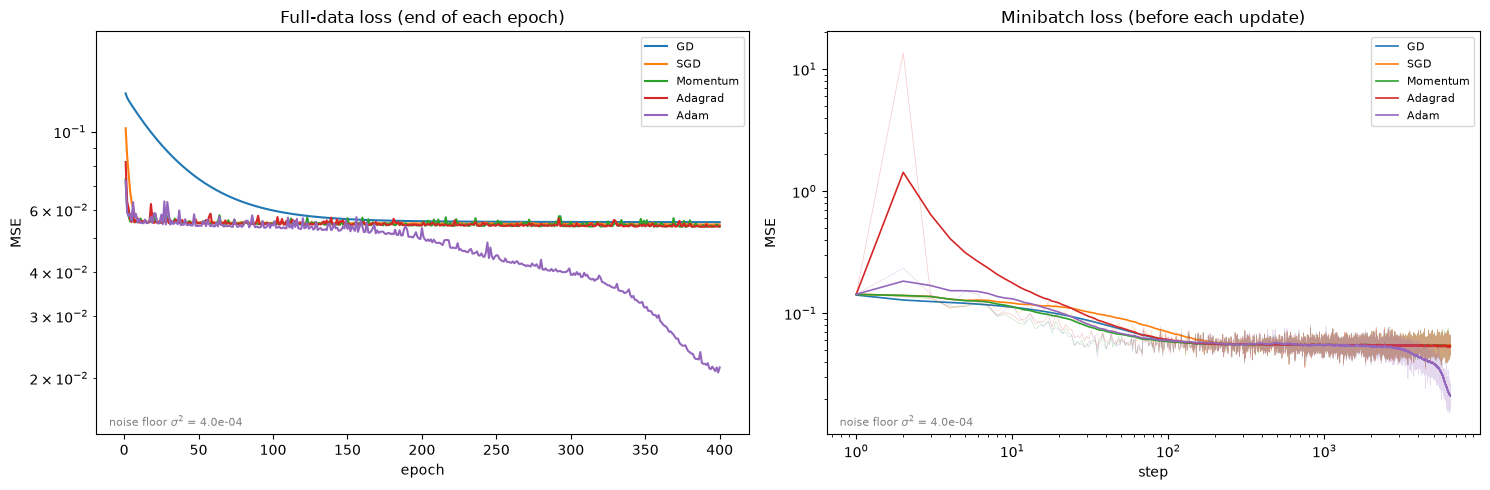

In [14]:
plot_loss_curves(results)

In [15]:
for name, (_, _, ep) in results.items():
    print(f"{name:10s} final full-data loss: {float(ep[-1]):.3e}")

GD         final full-data loss: 5.537e-02
SGD        final full-data loss: 5.452e-02
Momentum   final full-data loss: 5.371e-02
Adagrad    final full-data loss: 5.393e-02
Adam       final full-data loss: 2.143e-02


---
## 5. One more plot

Now make a plot I did not ask for.



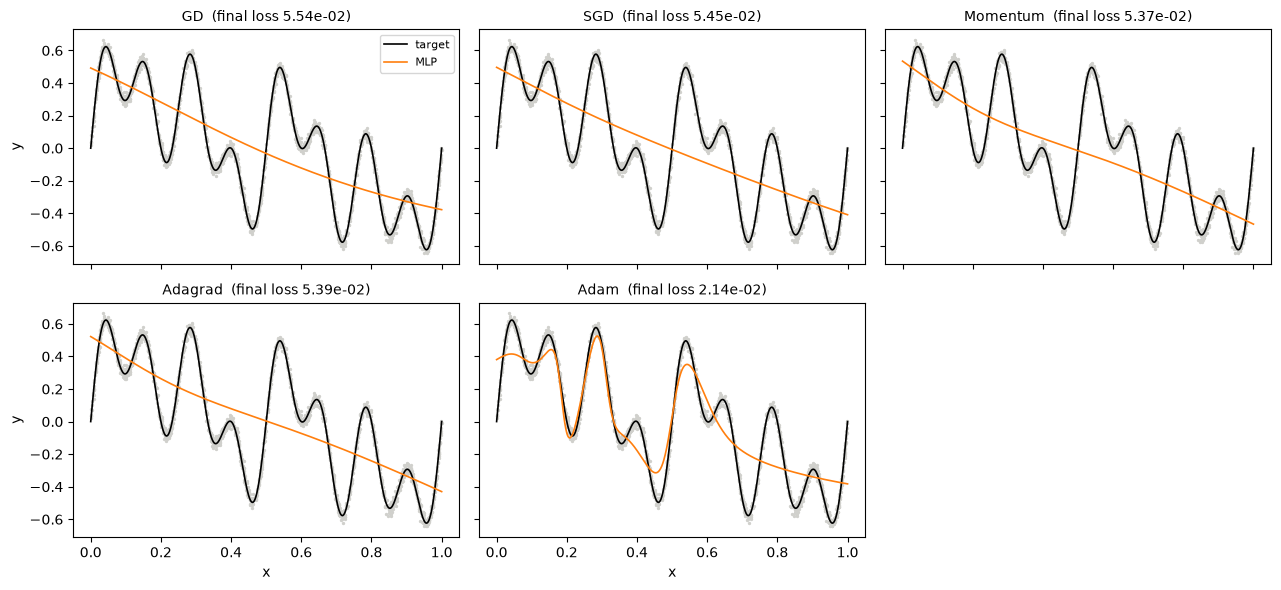

In [16]:
# original MLP fits of the data
plot_fits(results,X,Y)

In [18]:
# training loop but centering X around 0
def to_input(x):
    return 2*x-1
    
def from_input(u):               # inverts scaled data,[-1,1]-->[0,1] for data already stored in rescaled form
    return (u + 1) / 2

X_0mean = to_input(X)
runs_2 = {
    "GD":       (sgd(lr=0.01),       2048),
    "SGD":      (sgd(lr=0.01),       128),
    "Momentum": (sgd_momentum(lr=0.01,c=0.7),  128),
    "Adagrad": (adagrad(lr=0.01,), 128),
    "Adam": (adam(lr=0.0001, b1=0.9, b2=0.999, eps=1e-8), 128),
}

results_2 = run_all(runs_2,X_0mean)

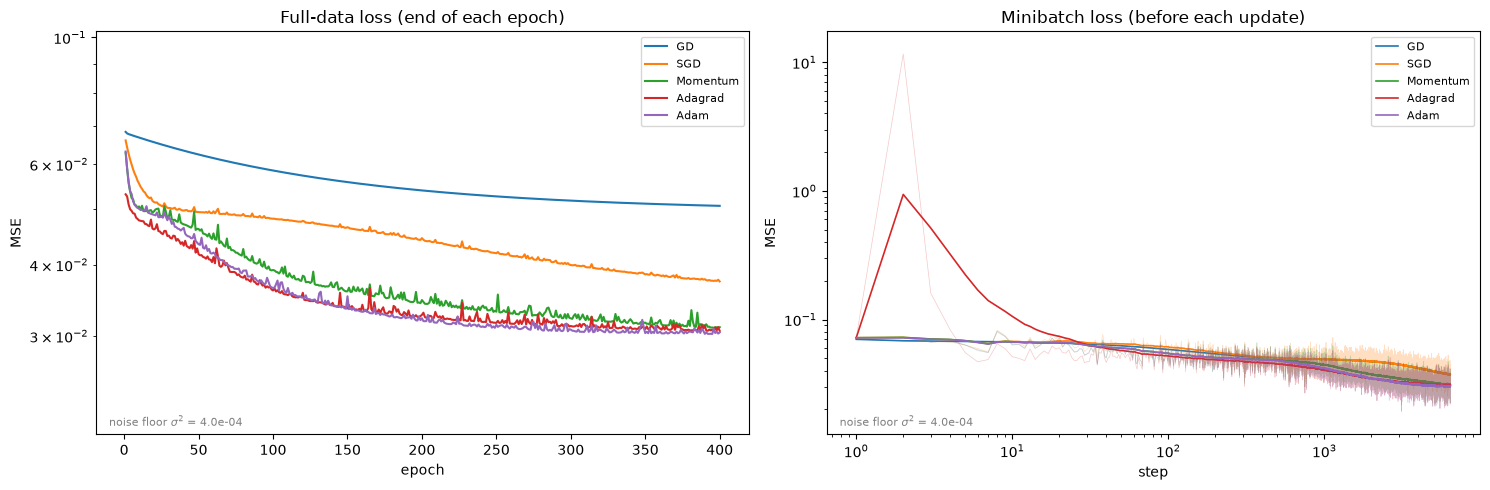

In [19]:
plot_loss_curves(results_2)

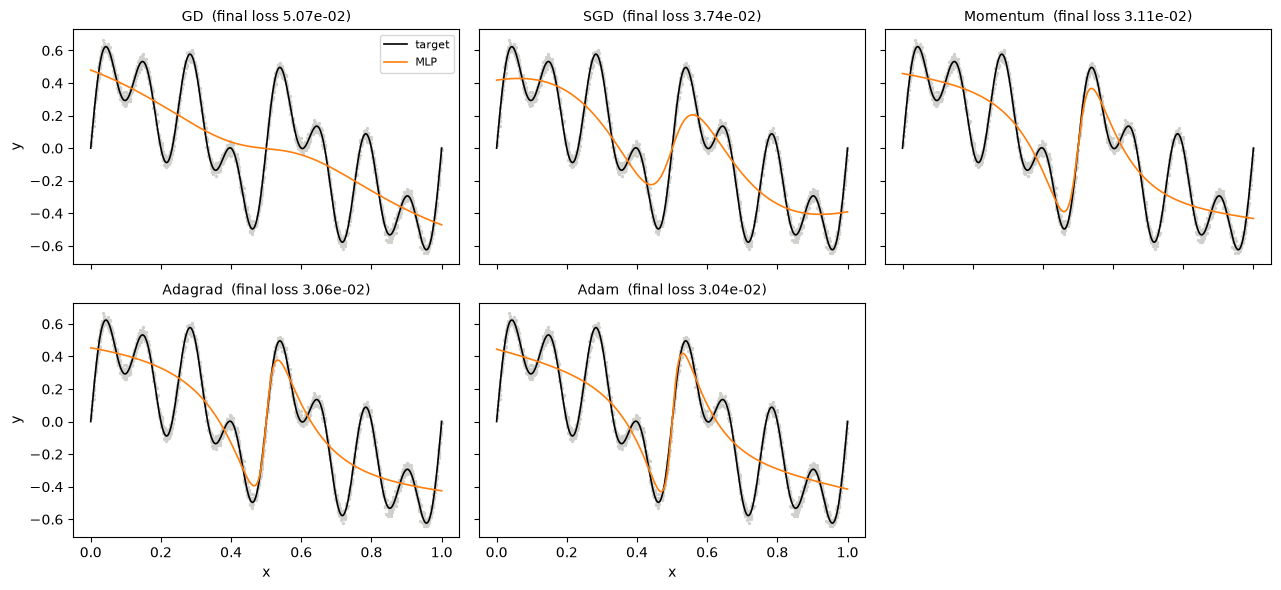

In [20]:
plot_fits(results_2,X,Y,to_input=to_input)

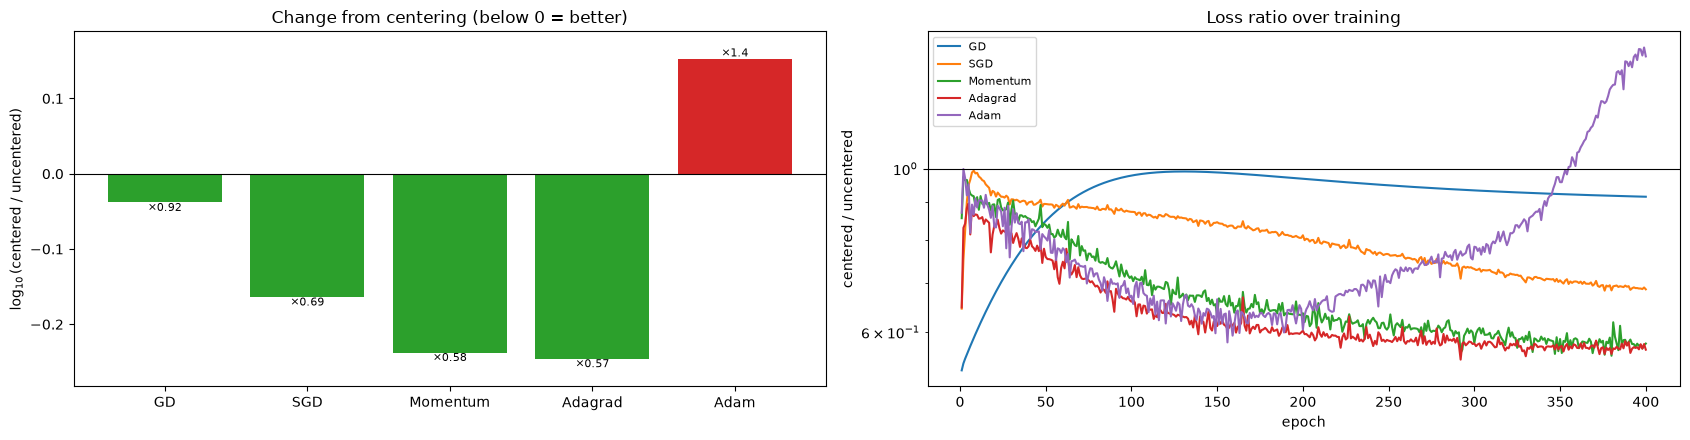

In [21]:
# difference between the two final full data losses
names = [k for k in results if k in results_2]            # optimizers present in both runs
final_raw = {k: float(results[k][2][-1])   for k in names}
final_ctr = {k: float(results_2[k][2][-1]) for k in names}
log_ratio = jax.tree.map(lambda a, b: np.log10(b / a), final_raw, final_ctr)

# the same idea for the full epoch curves (requires equal n_epochs in both runs)
curves_raw = {k: np.asarray(results[k][2])   for k in names}
curves_ctr = {k: np.asarray(results_2[k][2]) for k in names}
ratio_curves = jax.tree.map(lambda a, b: b / a, curves_raw, curves_ctr)

x = np.arange(len(names)); w = 0.38
fig, ( ax2, ax3) = plt.subplots(1, 2, figsize=(17, 4.5))


# log10 ratio of final losses
lr = np.array([log_ratio[k] for k in names]); ok = np.isfinite(lr)
ax2.bar(x[ok], lr[ok], color=np.where(lr[ok] < 0, "C2", "C3"))
ax2.axhline(0, color="black", lw=0.8)
for xi, v in zip(x, lr):
    label = f"×{10**v:.2g}" if np.isfinite(v) else "n/a (non-finite)"
    ax2.annotate(label, (xi, v if np.isfinite(v) else 0), ha="center",
                 va="bottom" if (not np.isfinite(v) or v >= 0) else "top", fontsize=8)
if ok.any():                                   # leave room for labels on both sides of 0
    span = max(np.abs(lr[ok]).max(), 1e-3)
    ax2.set_ylim(min(lr[ok].min(), 0) - 0.15 * span, max(lr[ok].max(), 0) + 0.15 * span)
ax2.set_xticks(x, names); ax2.set_ylabel(r"$\log_{10}$(centered / uncentered)")
ax2.set_title("Change from centering (below 0 = better)")

# ratio over the whole training run
for k in names:
    ax3.plot(np.arange(1, len(ratio_curves[k]) + 1), ratio_curves[k], label=k)
ax3.axhline(1, color="black", lw=0.8)
ax3.set_yscale("log"); ax3.set_xlabel("epoch"); ax3.set_ylabel("centered / uncentered")
ax3.set_title("Loss ratio over training"); ax3.legend(fontsize=8)

plt.tight_layout(); plt.show()